# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [41]:
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *

## Load organoid ensemble

In [42]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5-more" #"day4p5"
zarr_name = "r0.zarr"
well = "C01" #"A06"
round_name = "0_fused_zillum_registered"

# directory containing the organoid meshes
mesh_dir = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class"

# collect all VTP files
organoid_paths = sorted(glob.glob(os.path.join(mesh_dir, "*.vtp")))

# discard bad organoids
discard_ids = np.load('../NicoleData/combined_labels_to_discard.npy', allow_pickle=True)
kept_paths, discarded_paths = filter_organoid_paths(organoid_paths, discard_ids, timepoint, well)

print(f"Kept {len(kept_paths)} organoids, discarded {len(discarded_paths)}")

Kept 85 organoids, discarded 29


In [43]:
# ---------- Parameters ----------
dmax = 20
nbins = 32
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

k_values = [1, 3, 5]
n_perms = 999

# ---------- Storage for standard correlations ----------
Corr_all = []
Corr_conn_all = []

bins_dist_all = []
pair_counts_all = []
tot_area_all = []
tot_volume_all = []
num_cell_all = []

# ---------- Storage for binary seed enrichment ----------
Enrichment_all = []
F_local_all = []
F_global_all = []
Ns_enrich_all = []
hks_profile_all = []
hks_cell_mean_all = []
hks_cell_std_all = []

# ---------- Storage for kNN composition + Moran's I ----------
kNN_ensemble = {k: [] for k in k_values}             # list of object arrays per organoid
global_I_ensemble = {k: [] for k in k_values}        # list of (M, M) arrays
global_perm_ensemble = {k: [] for k in k_values}     # list of (n_perms, M, M) arrays

# ---------- Loop over organoids ----------
for path in kept_paths:
    print(f"Processing {path}")

    # -------------------- Mesh / fields --------------------
    mesh = OrganoidMesh()
    mesh.load_mesh_from_file(path)
    mesh.align_with_pca()
    try:
        _ = mesh.compute_spectral_coefficients(lmax=15)
    except Exception as e:
        print(f"Error processing mesh {path}: {e}")
        continue

    vertex_areas = mesh.calc_vertex_areas()
    volume = mesh.calc_mesh_volume()

    # HKS fields
    hks, hks_coeffs = compute_hks(mesh, t=[1.0])  # HKS at time scale comparable to cell size
    hks_removed_l0, _ = mesh.remove_lowest_modes(coeffs=hks_coeffs, l_remove=1)
    fields = np.concatenate([hks, hks_removed_l0], axis=1)

    # Coarse-grain to cell level
    cell_center_vertices = mesh.get_centroid_vertices()
    centroids, cell_areas, cell_weighted_fields, _ = mesh.compute_cell_statistics(fields)
    # fields_cell = fields[cell_center_vertices, :]
    fields_cell = cell_weighted_fields
    markers_cell = mesh.marker_fields[cell_center_vertices, :]

    # -------------------- Geodesics --------------------
    dist_heat = compute_geodesics(mesh, t=None, sources=cell_center_vertices)
    dist_heat = dist_heat[:, cell_center_vertices]

    bins_dist = pair_bins_by_distance(dist_heat, cell_areas, bin_edges, use_area_weights=False)
    counts_bin = np.array([len(bins_dist[f'I_{b}']) for b in range(len(bin_edges)-1)])

    # -------------------- Standard correlations --------------------
    Corr, Corr_conn, _, _ = compute_two_point_correlations(bins_dist, fields_cell)

    # -------------------- Binary seed-anchored enrichment --------------------
    positive_indices, positive_labels = positive_indices_and_labels(markers_cell)
    num_markers = positive_labels.shape[1]
    
    hks_cell_mean, hks_cell_std, _ = local_field_statistics(fields_cell[:,1], positive_labels)

    enrichment_per_organoid = np.zeros((num_markers, len(bin_centers), num_markers))
    f_local_per_organoid = np.zeros_like(enrichment_per_organoid)
    f_global_per_organoid = np.zeros((num_markers, num_markers))
    Ns_per_organoid = np.zeros(len(bin_centers))
    hks_profile_per_organoid = np.zeros((num_markers, len(bin_centers)))

    for m_idx in range(num_markers):

        seeds = positive_indices[m_idx]
        if len(seeds) == 0:
            enrichment_per_organoid[m_idx, :, :] = np.nan
            f_local_per_organoid[m_idx, :, :] = np.nan
            f_global_per_organoid[m_idx, :] = np.nan
            hks_profile_per_organoid[m_idx, :] = np.nan
            continue

        bins_sources = pair_bins_by_distance(
            dist_heat, cell_areas, bin_edges, sources=seeds, use_area_weights=False
        )
        enrichment, f_local, f_global, Ns_bin = compute_anchored_enrichment(bins_sources, positive_labels)

        # compute anchored profile of HKS with l>0
        hks_profile, _ = compute_anchored_radial_profile(
            bins_sources, fields_cell[:, 1]
        )

        enrichment_per_organoid[m_idx, :, :] = enrichment
        f_local_per_organoid[m_idx, :, :] = f_local
        f_global_per_organoid[m_idx, :] = f_global
        Ns_per_organoid = Ns_bin  # same for all markers
        hks_profile_per_organoid[m_idx, :] = hks_profile


    # -------------------- kNN composition + Moran's I --------------------
    cell_graph = build_cell_graph(mesh)
    for k in k_values:
        # kNN composition for each focal marker
        comp_per_marker = []
        for focal_idx in range(num_markers):
            try:
                _, _, _, comp_accum = kNN_marker_composition(
                    cell_graph, positive_labels, focal_marker_idx=focal_idx, k=k
                )
                comp_per_marker.append(comp_accum)
            except ValueError:
                comp_per_marker.append(None)

        comp_per_marker = np.array(comp_per_marker, dtype=object)
        kNN_ensemble[k].append(comp_per_marker)

        # Moran's I permutation test
        W, nodes = build_weight_matrix_kNN(cell_graph, k=k, row_standardize=False)
        global_I_obs, local_I_obs, global_I_perm, p_values = permutation_test_morans_I(
            positive_labels, W, Y=positive_labels, n_perms=n_perms
        )
        global_I_ensemble[k].append(global_I_obs)
        global_perm_ensemble[k].append(global_I_perm)

    # -------------------- Store --------------------
    Corr_all.append(Corr)
    Corr_conn_all.append(Corr_conn)
    bins_dist_all.append(bins_dist)
    pair_counts_all.append(counts_bin)
    tot_area_all.append(np.sum(vertex_areas))
    tot_volume_all.append(volume)
    num_cell_all.append(cell_areas.shape[0])

    Enrichment_all.append(enrichment_per_organoid)
    F_local_all.append(f_local_per_organoid)
    F_global_all.append(f_global_per_organoid)
    Ns_enrich_all.append(Ns_per_organoid)

    hks_profile_all.append(hks_profile_per_organoid)
    hks_cell_mean_all.append(hks_cell_mean)
    hks_cell_std_all.append(hks_cell_std)


# ---------- Postprocessing: aggregate kNN + Moran's I ----------
for k in k_values:
    global_I_ensemble[k] = np.stack(global_I_ensemble[k], axis=0)        # (n_organoids, M, M)
    global_perm_ensemble[k] = np.stack(global_perm_ensemble[k], axis=0)  # (n_organoids, n_perms, M, M)

ensemble_global_I_mean = {k: np.nanmean(global_I_ensemble[k], axis=0) for k in k_values}

ensemble_global_perm = {}
ensemble_p_values = {}
for k in k_values:
    perm_all = np.concatenate(global_perm_ensemble[k], axis=0)  # (n_org*n_perms, M, M)
    ensemble_global_perm[k] = perm_all

    obs_mean = ensemble_global_I_mean[k]
    p_val = np.mean(np.abs(perm_all) >= np.abs(obs_mean[None, :, :]), axis=0)
    ensemble_p_values[k] = p_val


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/1.vtp
[Info] Eigen-decomposition not found. Computing now...


heat sources: 100%|██████████| 295/295 [00:01<00:00, 196.62it/s]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:308: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:310: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/100.vtp
[Info] Eigen-decomposition not found. Computing now...


heat sources: 100%|██████████| 56/56 [00:00<00:00, 199.26it/s]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:308: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:310: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/101.vtp
[Info] Eigen-decomposition not found. Computing now...


...

heat sources: 100%|██████████| 390/390 [00:01<00:00, 195.77it/s]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:308: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:310: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/96.vtp
[Info] Eigen-decomposition not found. Computing now...


heat sources: 100%|██████████| 62/62 [00:00<00:00, 185.10it/s]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:308: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:310: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/98.vtp
[Info] Eigen-decomposition not found. Computing now...


heat sources: 100%|██████████| 238/238 [00:01<00:00, 180.91it/s]


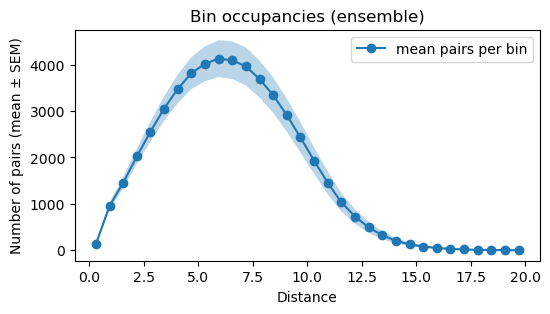

In [44]:
pair_counts_arr = np.stack(pair_counts_all, axis=0)  # (n_org, B)
mean_counts = pair_counts_arr.mean(axis=0)
std_counts = pair_counts_arr.std(axis=0, ddof=1)
sem_counts = std_counts / np.sqrt(pair_counts_arr.shape[0])

plt.figure(figsize=(6,3))
plt.plot(bin_centers, mean_counts, 'o-', label='mean pairs per bin')
plt.fill_between(bin_centers, mean_counts - sem_counts, mean_counts + sem_counts, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Number of pairs (mean ± SEM)")
plt.title("Bin occupancies (ensemble)")
plt.legend()
plt.show()


In [45]:
import scikits.bootstrap as boot

# Stack correlations: shape (n_org, B, F, F)
Corr_all = np.stack(Corr_all, axis=0)
Corr_conn_all = np.stack(Corr_conn_all, axis=0)

n_org, B, F, _ = Corr_all.shape

# --- Helper function to bootstrap CI for a 1D array ---
def bootstrap_ci_1d(data, alpha=0.05, n_samples=2000):
    ci = boot.ci(
        data,
        statfunction=np.nanmean,
        method='bca',
        alpha=alpha,
        n_samples=n_samples
    )
    return ci[0], ci[1]  # (low, high)

# --- Arrays to store CIs ---
# Each: (B, F), one for raw correlations and one for connected
ci_low_C = np.zeros((B, F))
ci_high_C = np.zeros((B, F))
ci_low_Cconn = np.zeros((B, F))
ci_high_Cconn = np.zeros((B, F))

# --- Loop over bins and fields ---
for f in range(F):
    # Auto-correlations only: i=j=f
    data_C = Corr_all[:, :, f, f].T        # shape (B, n_org)
    data_Cconn = Corr_conn_all[:, :, f, f].T

    for b in range(B):
        ci_low_C[b, f], ci_high_C[b, f] = bootstrap_ci_1d(data_C[b])
        ci_low_Cconn[b, f], ci_high_Cconn[b, f] = bootstrap_ci_1d(data_Cconn[b])

# --- Optional: package nicely ---
# ci_low_C[b, f] is the lower CI for bin b, field f (raw correlations)
# ci_low_Cconn[b, f] is the lower CI for bin b, field f (connected correlations)

print("CIs computed:")
print("Raw correlations CI arrays shape:", ci_low_C.shape)
print("Connected correlations CI arrays shape:", ci_low_Cconn.shape)


/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = b

CIs computed:
Raw correlations CI arrays shape: (32, 2)
Connected correlations CI arrays shape: (32, 2)


/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_2779592/1394910444.py:11: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(


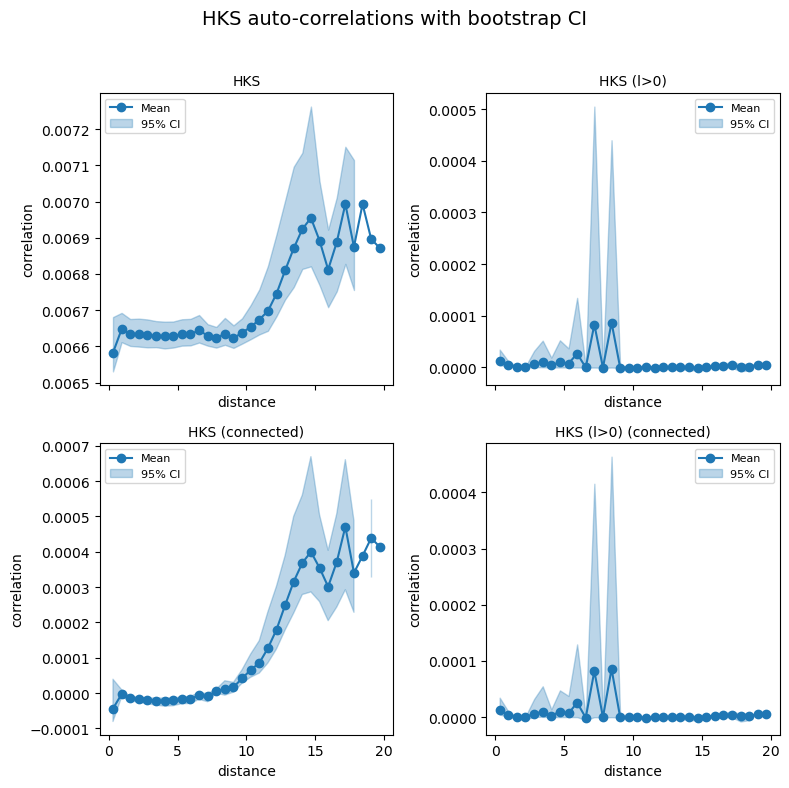

In [46]:
B = bin_centers.shape[0]
F = Corr_all.shape[2]   # number of markers

# Compute mean across organoids for autocorrelations (i = j)
C_mean = np.nanmean(np.array([Corr_all[:, :, k, k] for k in range(F)]), axis=1).T    # (B, F)
C_conn_mean = np.nanmean(np.array([Corr_conn_all[:, :, k, k] for k in range(F)]), axis=1).T

corr_names = [
    ["HKS", "HKS (l>0)"],
    ["HKS (connected)", "HKS (l>0) (connected)"]
]

fig, axes = plt.subplots(2, F, figsize=(8, 8), sharex=True, sharey=False)

for j in range(F):
    # --- Top row: raw auto-correlations ---
    ax = axes[0, j]
    y = C_mean[:, j]
    y_low = ci_low_C[:, j]
    y_high = ci_high_C[:, j]

    ax.plot(bin_centers, y, 'o-', label='Mean')
    ax.fill_between(bin_centers, y_low, y_high, color='C0', alpha=0.3, label='95% CI')

    ax.set_title(corr_names[0][j], fontsize=10)
    ax.set_ylabel("correlation", fontsize=10)
    ax.set_xlabel("distance", fontsize=10)
    ax.legend(fontsize=8)

    # --- Bottom row: connected auto-correlations ---
    ax = axes[1, j]
    y = C_conn_mean[:, j]
    y_low = ci_low_Cconn[:, j]
    y_high = ci_high_Cconn[:, j]

    ax.plot(bin_centers, y, 'o-', label='Mean')
    ax.fill_between(bin_centers, y_low, y_high, color='C0', alpha=0.3, label='95% CI')

    ax.set_title(corr_names[1][j], fontsize=10)
    ax.set_ylabel("correlation", fontsize=10)
    ax.set_xlabel("distance", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("HKS auto-correlations with bootstrap CI", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Group organoids

If the organoids do not develop any protrusions, i.e. they are sphere-like, they will likely show different correlation behavior. Hence it may be worth exploring whether we need to calculate correlations across groups, rather than days. 

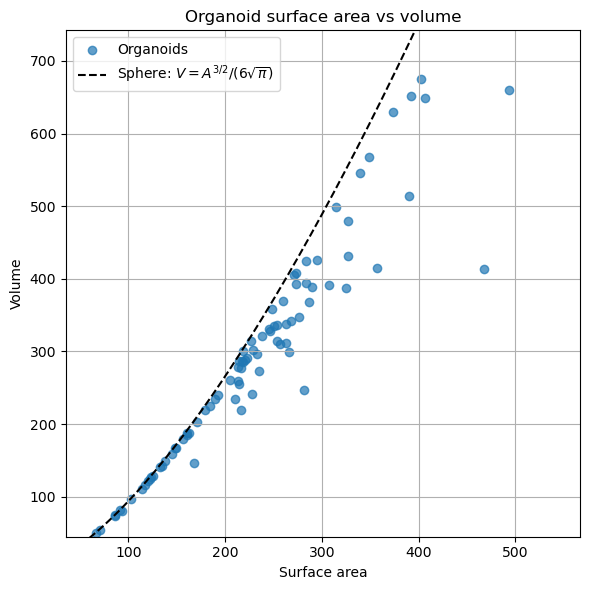

In [47]:
tot_area_all = np.stack(tot_area_all, axis=0)
tot_volume_all = np.stack(tot_volume_all, axis=0)

plt.figure(figsize=(6,6))
plt.scatter(tot_area_all, tot_volume_all, alpha=0.7, label="Organoids")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()



In [48]:
compactness = tot_area_all / (tot_volume_all ** (2.0/3.0))

comp_sphere = 4.835
threshold = 1.20 * comp_sphere   # 20% larger than sphere
group_sphere_like = (compactness <= threshold) & (tot_volume_all >= 200)
group_protruded   = (compactness > threshold) & (tot_volume_all >= 200)

print(np.sum(group_sphere_like))
print(np.sum(group_protruded))

52
9


/tmp/ipykernel_2779592/1199611097.py:2: RuntimeWarning: Mean of empty slice
  Corr_sphere = np.nanmean(Corr_conn_all[group_sphere_like], axis=0)       # (B,F,F)


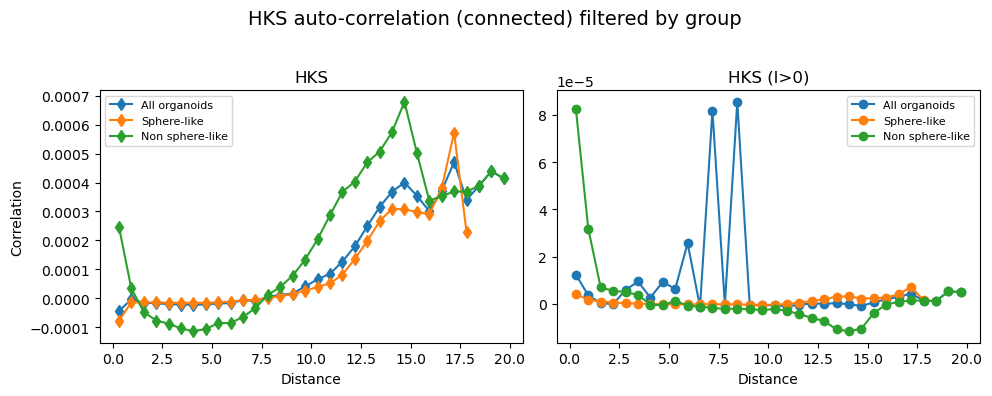

In [49]:
# Compute group means
Corr_sphere = np.nanmean(Corr_conn_all[group_sphere_like], axis=0)       # (B,F,F)
Corr_protruded = np.nanmean(Corr_conn_all[group_protruded], axis=0)      # (B,F,F)
Corr_all_mean = np.nanmean(Corr_conn_all, axis=0)                        # (B,F,F)

# --- Create subplots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

# ---------------------------
# Subplot 1: HKS (0,0)
# ---------------------------
ax = axes[0]
ax.plot(bin_centers, Corr_all_mean[:,0,0], 'd-', label="All organoids")
ax.plot(bin_centers, Corr_sphere[:,0,0], 'd-', label="Sphere-like")
ax.plot(bin_centers, Corr_protruded[:,0,0], 'd-', label="Non sphere-like")
ax.set_title("HKS")
ax.set_xlabel("Distance")
ax.set_ylabel("Correlation")
ax.legend(fontsize=8)

# ---------------------------
# Subplot 2: HKS (l>0) (1,1)
# ---------------------------
ax = axes[1]
ax.plot(bin_centers, Corr_all_mean[:,1,1], 'o-', label="All organoids")
ax.plot(bin_centers, Corr_sphere[:,1,1], 'o-', label="Sphere-like")
ax.plot(bin_centers, Corr_protruded[:,1,1], 'o-', label="Non sphere-like")
ax.set_title("HKS (l>0)")
ax.set_xlabel("Distance")
ax.legend(fontsize=8)

fig.suptitle("HKS auto-correlation (connected) filtered by group", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [50]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.cluster import KMeans


def cluster_correlations(C_all, threshold = 0.8, k=2):

    # C_all: (n_org, B) correlation curves (NaNs at long distances)
    n_org, B = C_all.shape

    # 1) compute coverage per bin
    valid_counts = np.sum(~np.isnan(C_all), axis=0)   # shape (B,)
    frac = valid_counts / n_org

    # 2) choose bins where fraction >= threshold
    mask_bins = frac >= threshold
    print("Using", mask_bins.sum(), "bins out of", B)

    # 3) build feature matrix truncated
    X = C_all[:, mask_bins]

    # 4) for each organoid, if there are still NaNs inside truncated region (rare), impute with linear interp or fill with bin mean
    for i in range(n_org):
        row = X[i]
        if np.isnan(row).any():
            # linear interp across available points
            good = ~np.isnan(row)
            if good.sum() >= 2:
                xp = np.where(good)[0]
                fp = row[good]
                x = np.arange(len(row))
                X[i] = np.interp(x, xp, fp)
            else:
                # fallback: fill with zeros
                X[i] = np.nan_to_num(row, nan=0.0)

    # 5) standardize per-sample (z-score) or globally. Here per-sample:
    # Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    # Xz = (X ) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    # Xz = (X ) / (X.mean(axis=1, keepdims=True) + 1e-12)
    Xz = X

    # 6) cluster
    km = KMeans(n_clusters=k, random_state=0).fit(Xz)
    labels = km.labels_

    return km, labels, mask_bins, Xz

Using 16 bins out of 29
41
1
15
4


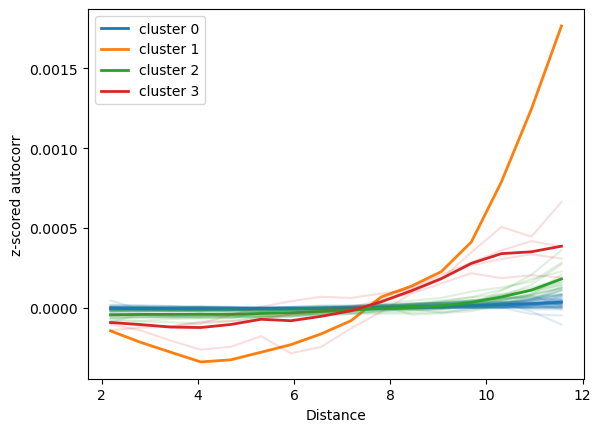

In [72]:
vol_min = 200
start_bin = 3

C_cluster = Corr_conn_all[tot_volume_all>vol_min,start_bin:,0,0]

km, labels, mask_bins, Cz = cluster_correlations(C_cluster, k=4, threshold=0.95)


centroids = km.cluster_centers_
bin_cluster = bin_centers[start_bin:]
r_plot = bin_cluster[mask_bins]
plt.figure()
for c in range(km.n_clusters):
    members = Cz[labels==c]

    print(members.shape[0])

    # plot member curves lightly
    for row in members:
        plt.plot(r_plot, row, color=f"C{c}", alpha=0.15)
    # plot centroid
    plt.plot(r_plot, centroids[c], color=f"C{c}", lw=2, label=f"cluster {c}")
plt.legend()
plt.xlabel("Distance")
plt.ylabel("z-scored autocorr")
plt.show()

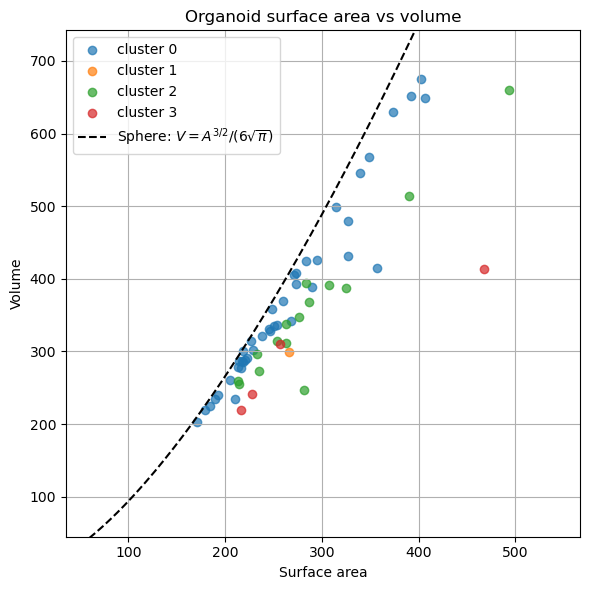

In [73]:
tot_area_tmp = tot_area_all[tot_volume_all>vol_min]
tot_volume_tmp = tot_volume_all[tot_volume_all>vol_min]

plt.figure(figsize=(6,6))
for c in range(km.n_clusters):
    plt.scatter(tot_area_tmp[labels==c], tot_volume_tmp[labels==c], color=f"C{c}", alpha=0.7, label=f"cluster {c}")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()

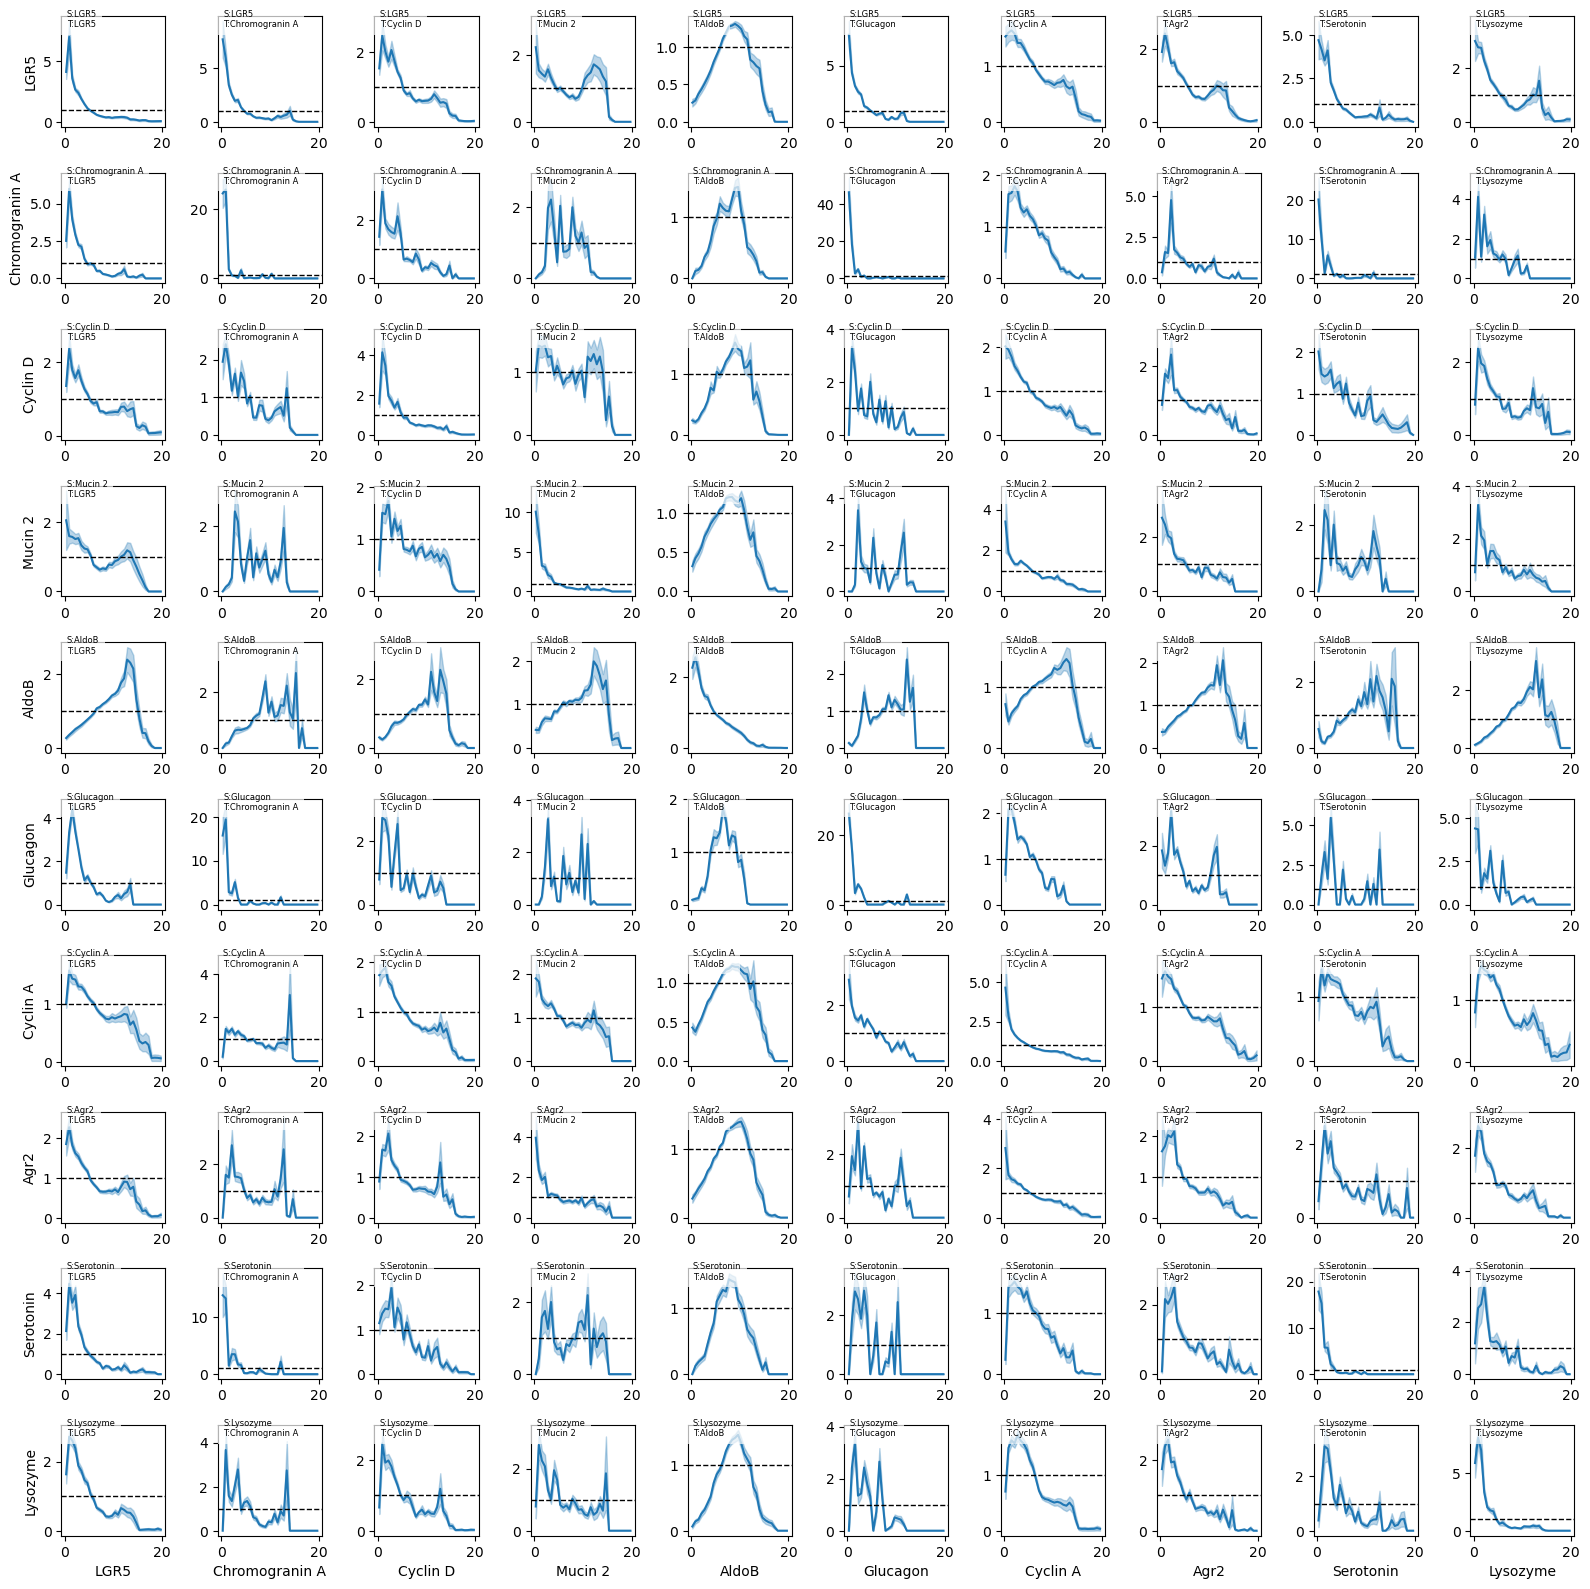

In [74]:

# Convert list to ndarray
Enrichment_arr = np.stack(Enrichment_all, axis=0)

n_organoids, n_markers, nbins, _ = Enrichment_arr.shape



# Ensemble mean and SEM
Enrichment_mean = np.nanmean(Enrichment_arr, axis=0)  # (nbins, n_markers-1)
Enrichment_std  = np.nanstd(Enrichment_arr, axis=0)
Enrichment_sem  = Enrichment_std / np.sqrt(n_organoids)


# -------------------- Plot cross-enrichment grid --------------------
fig, axes = plt.subplots(n_markers, n_markers,
                         figsize=(16, 16),
                         sharex=False, sharey=False)

for i_source in range(n_markers):
    for j_target in range(n_markers):
        ax = axes[i_source, j_target]

        # Plot ensemble-averaged enrichment
        ax.plot(bin_centers, Enrichment_mean[i_source, :, j_target], color='tab:blue')
        ax.fill_between(bin_centers,
                        Enrichment_mean[i_source, :, j_target] - Enrichment_sem[i_source, :, j_target],
                        Enrichment_mean[i_source, :, j_target] + Enrichment_sem[i_source, :, j_target],
                        alpha=0.3, color='tab:blue')

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)

        # Axis labels
        if i_source == n_markers - 1:
            ax.set_xlabel(f"{mesh.marker_names[j_target]}", fontsize=10)
        if j_target == 0:
            ax.set_ylabel(f"{mesh.marker_names[i_source]}", fontsize=10)

        ax.tick_params(axis='both', which='major', labelsize=10)

        # Add label inside subplot for quick identification
        ax.text(0.05, 0.9, f"S:{mesh.marker_names[i_source]}\nT:{mesh.marker_names[j_target]}",
                transform=ax.transAxes, fontsize=6, color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()


(0.0, 10.0)

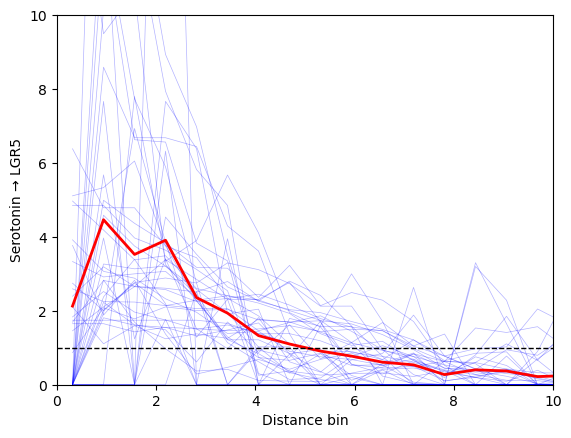

In [75]:
# --- Choose one source and one target ---
i_source = 8   # 
j_target = 0   # 



curves = Enrichment_arr[:, i_source, :, j_target]

# Plot each organoid curve (thin, transparent)
for c in curves:
    plt.plot(bin_centers, c, color="blue", linewidth=0.5, alpha=0.3)

# Compute mean curve
mean_curve = np.nanmean(curves, axis=0)

# Plot mean (thicker)
plt.plot(bin_centers, mean_curve, color="red", linewidth=2, label="Mean")

# Horizontal line at 1
plt.axhline(1.0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Distance bin")
plt.ylabel(f"{mesh.marker_names[i_source]} → {mesh.marker_names[j_target]}")

plt.xlim((0, 10))
plt.ylim((0, 10))


Text(0.5, 0.98, 'kNN Neighbor Compositions Across Organoids')

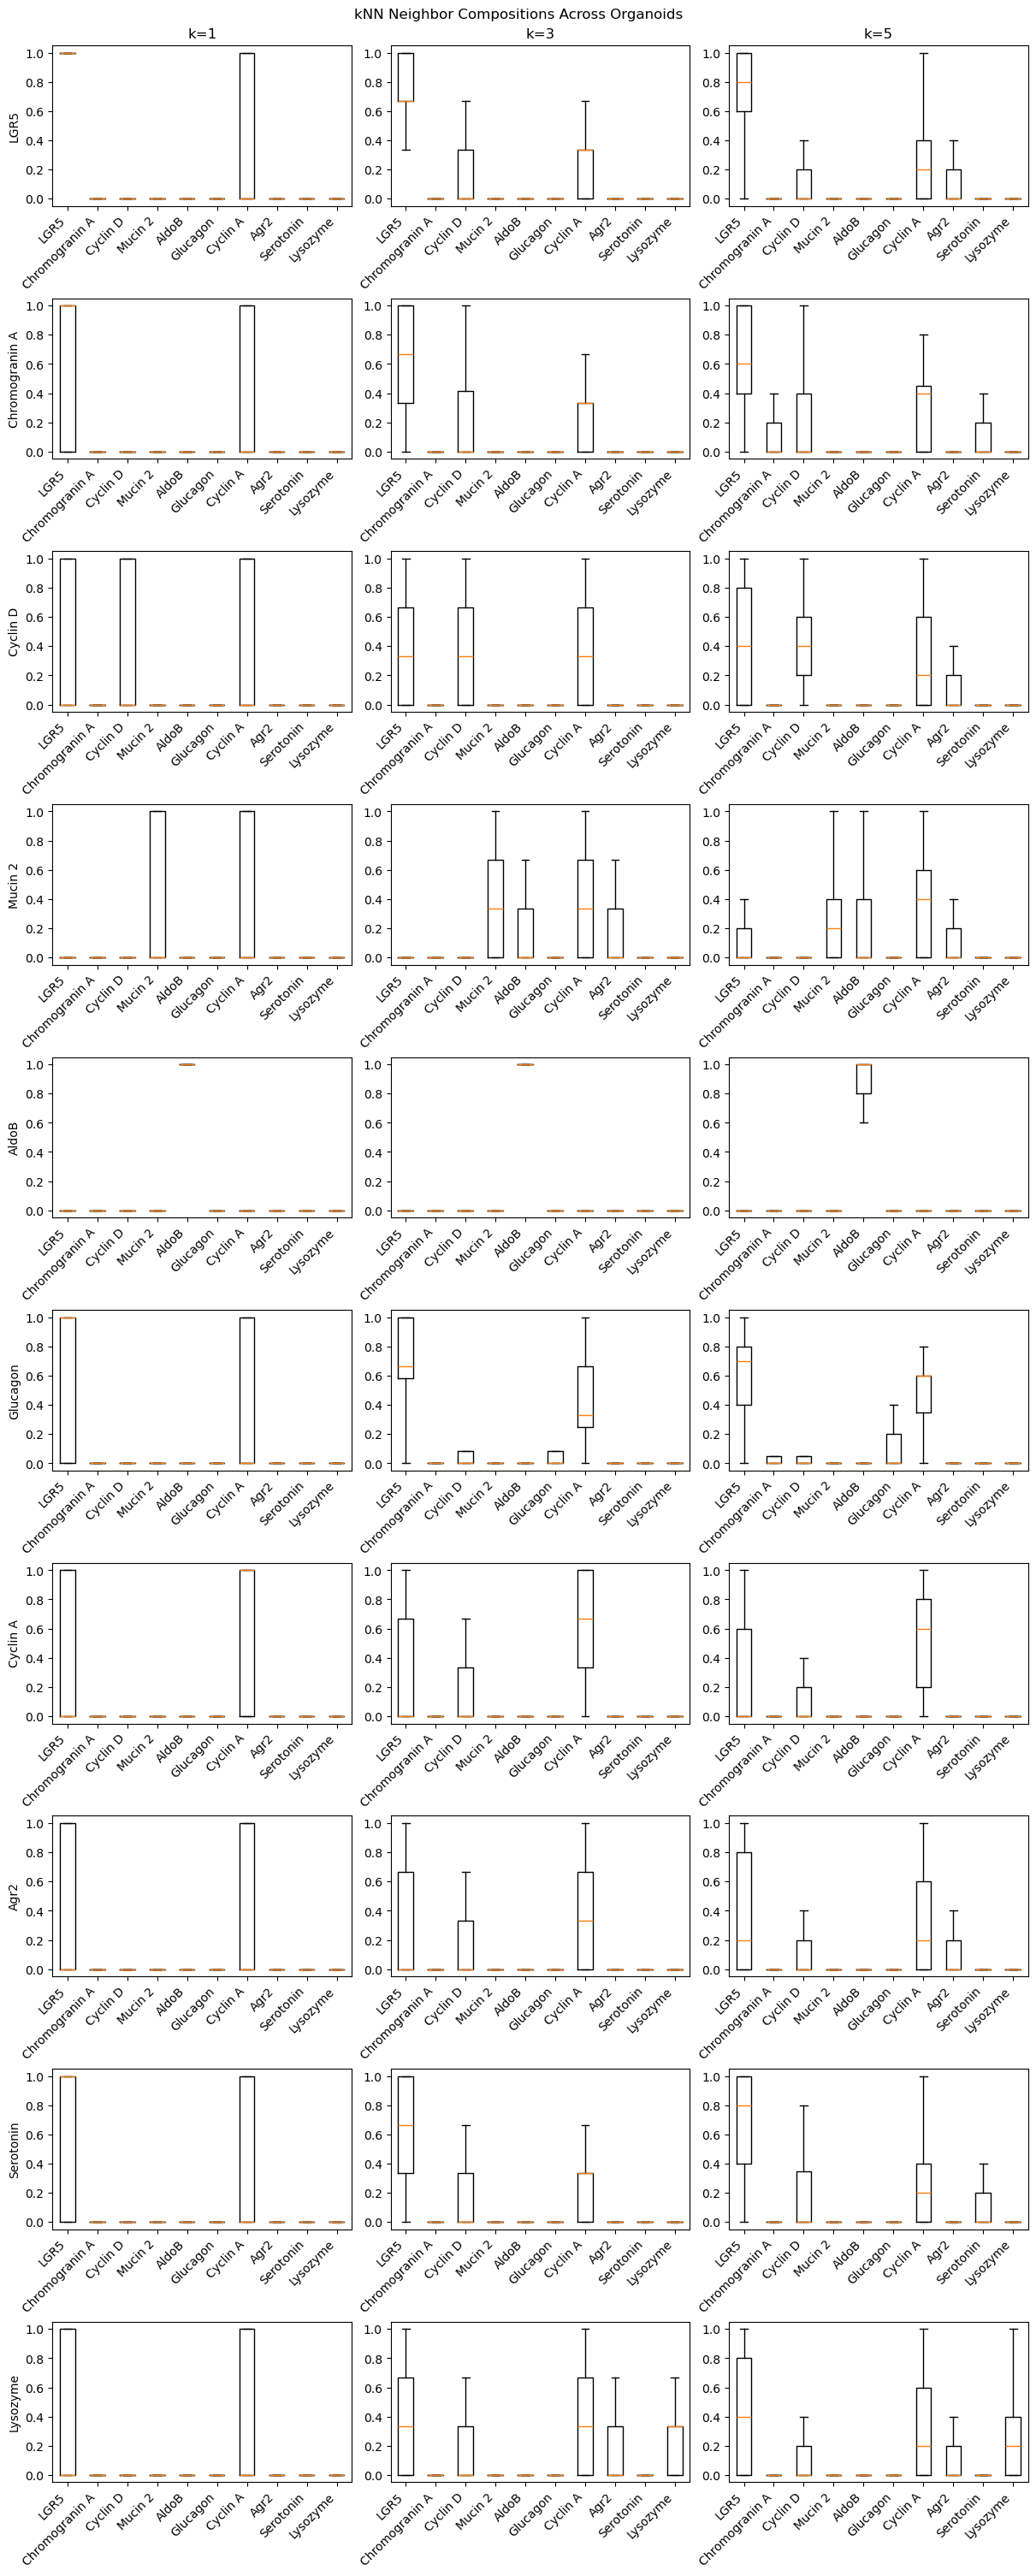

In [76]:
n_k = len(k_values)
fig, axes = plt.subplots(n_markers, n_k, figsize=(4*n_k, 3*n_markers), constrained_layout=True)

# Ensure axes is 2D array even if n_markers or n_k == 1
if n_markers == 1:
    axes = axes[None, :]
if n_k == 1:
    axes = axes[:, None]

for i, focal_idx in enumerate(range(n_markers)):
    for j, k in enumerate(k_values):
        # Gather pooled compositions across all organoids
        pooled = []
        for comp_per_organoid in kNN_ensemble[k]:
            arr = comp_per_organoid[focal_idx]
            if arr is not None:
                pooled.append(arr)
        if len(pooled) == 0:
            pooled_arr = np.full((1, n_markers), np.nan)
        else:
            pooled_arr = np.concatenate(pooled, axis=0)  # shape (total_cells, n_markers)

        # Create boxplot: one box per neighbor marker
        ax = axes[i, j]
        ax.boxplot(pooled_arr, showfliers=False)
        if i == 0:
            ax.set_title(f"k={k}")
        if j == 0:
            ax.set_ylabel(mesh.marker_names[focal_idx])
        
        ax.set_xticks(range(1, n_markers+1))
        ax.set_xticklabels(mesh.marker_names, rotation=45, ha='right')

plt.suptitle("kNN Neighbor Compositions Across Organoids")

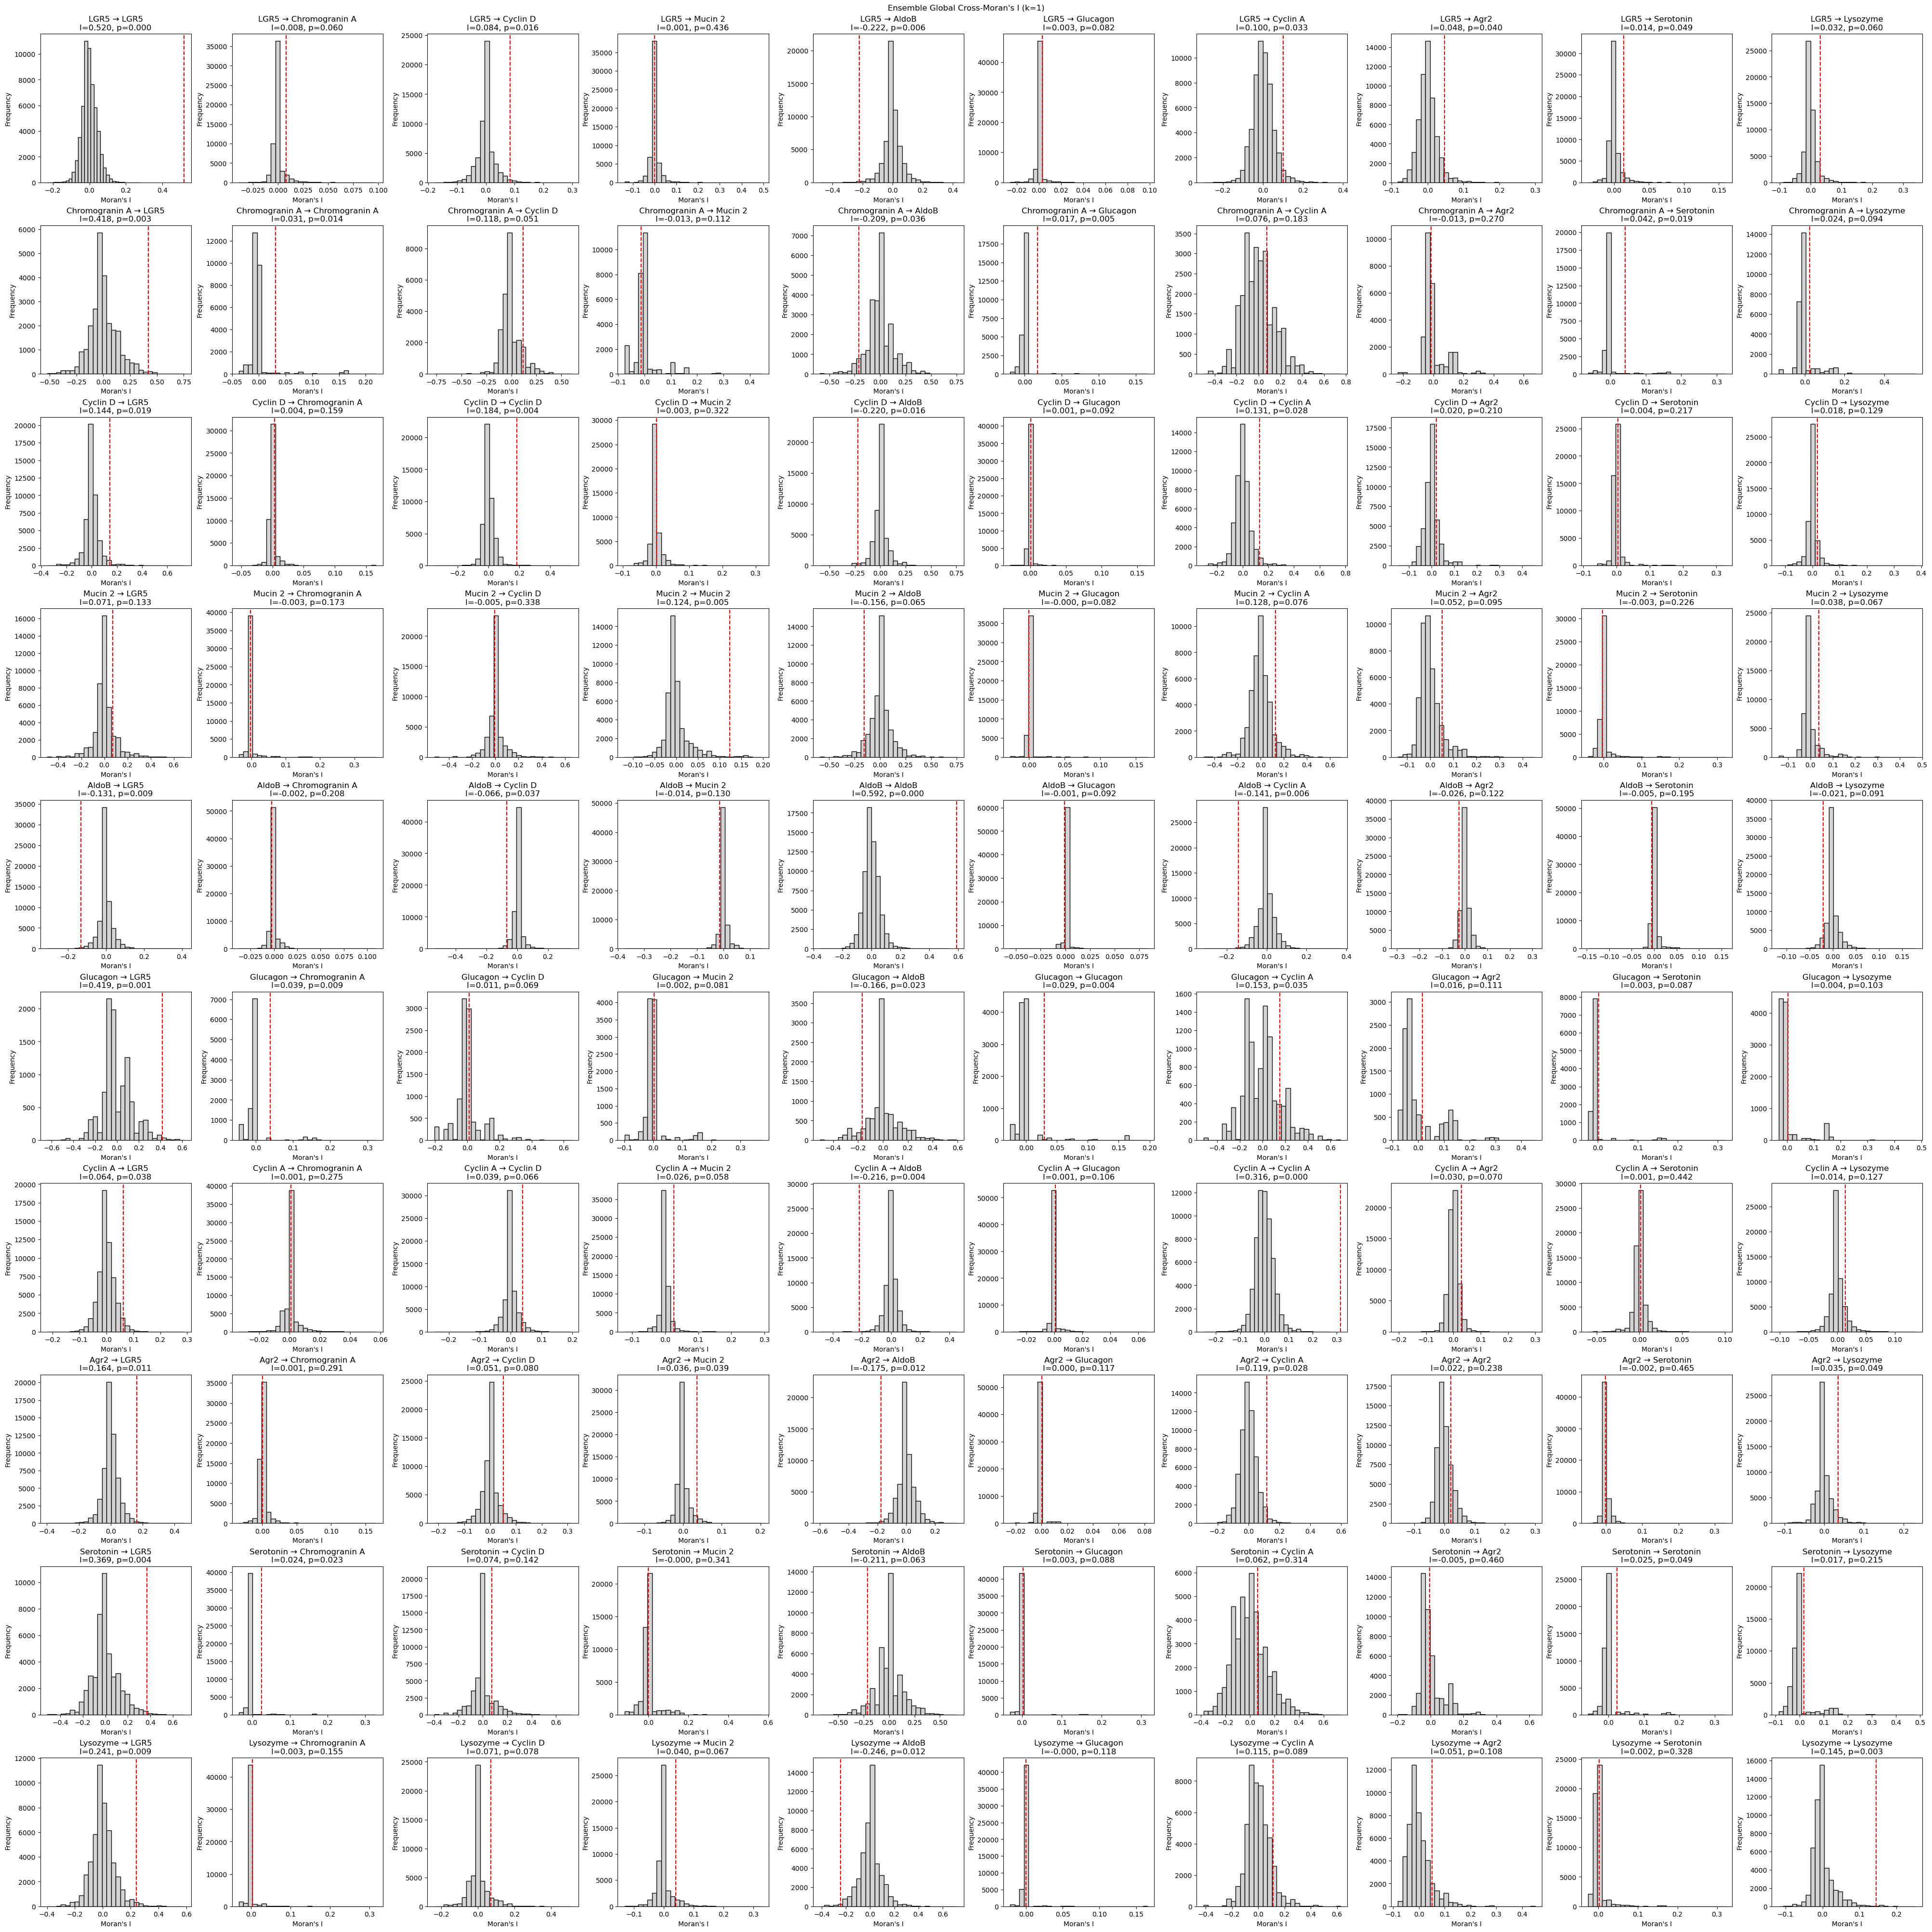

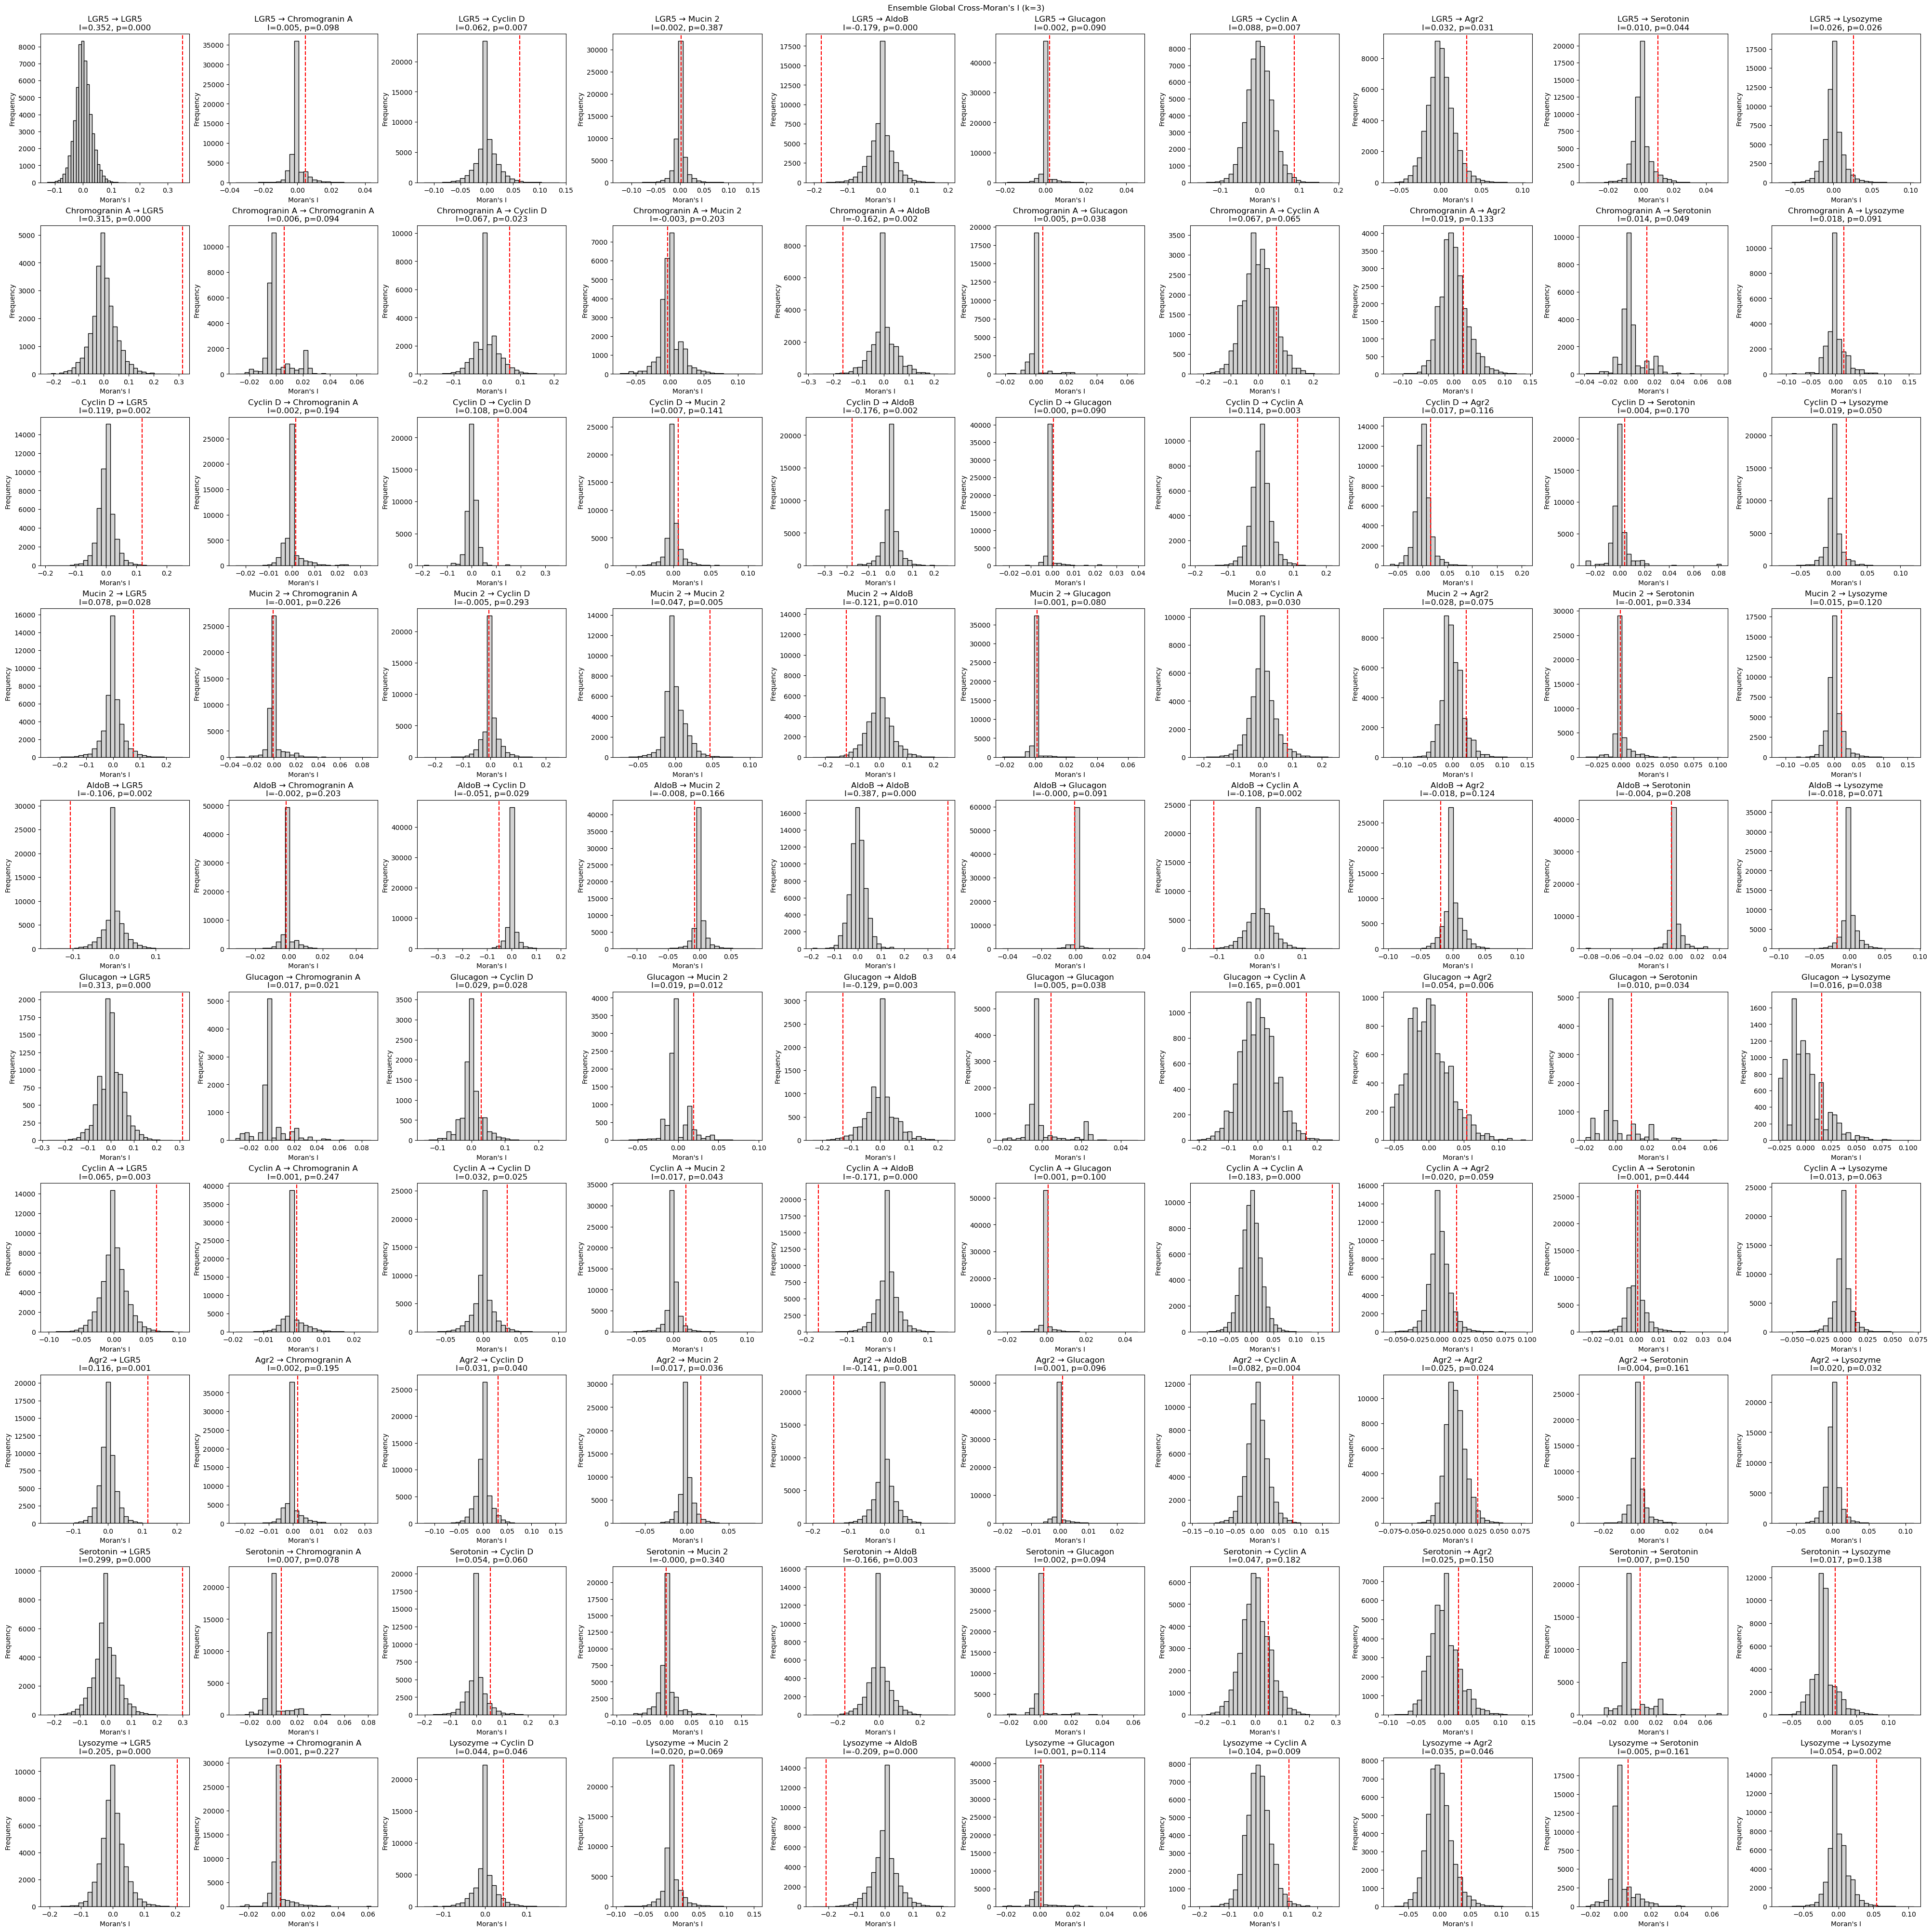

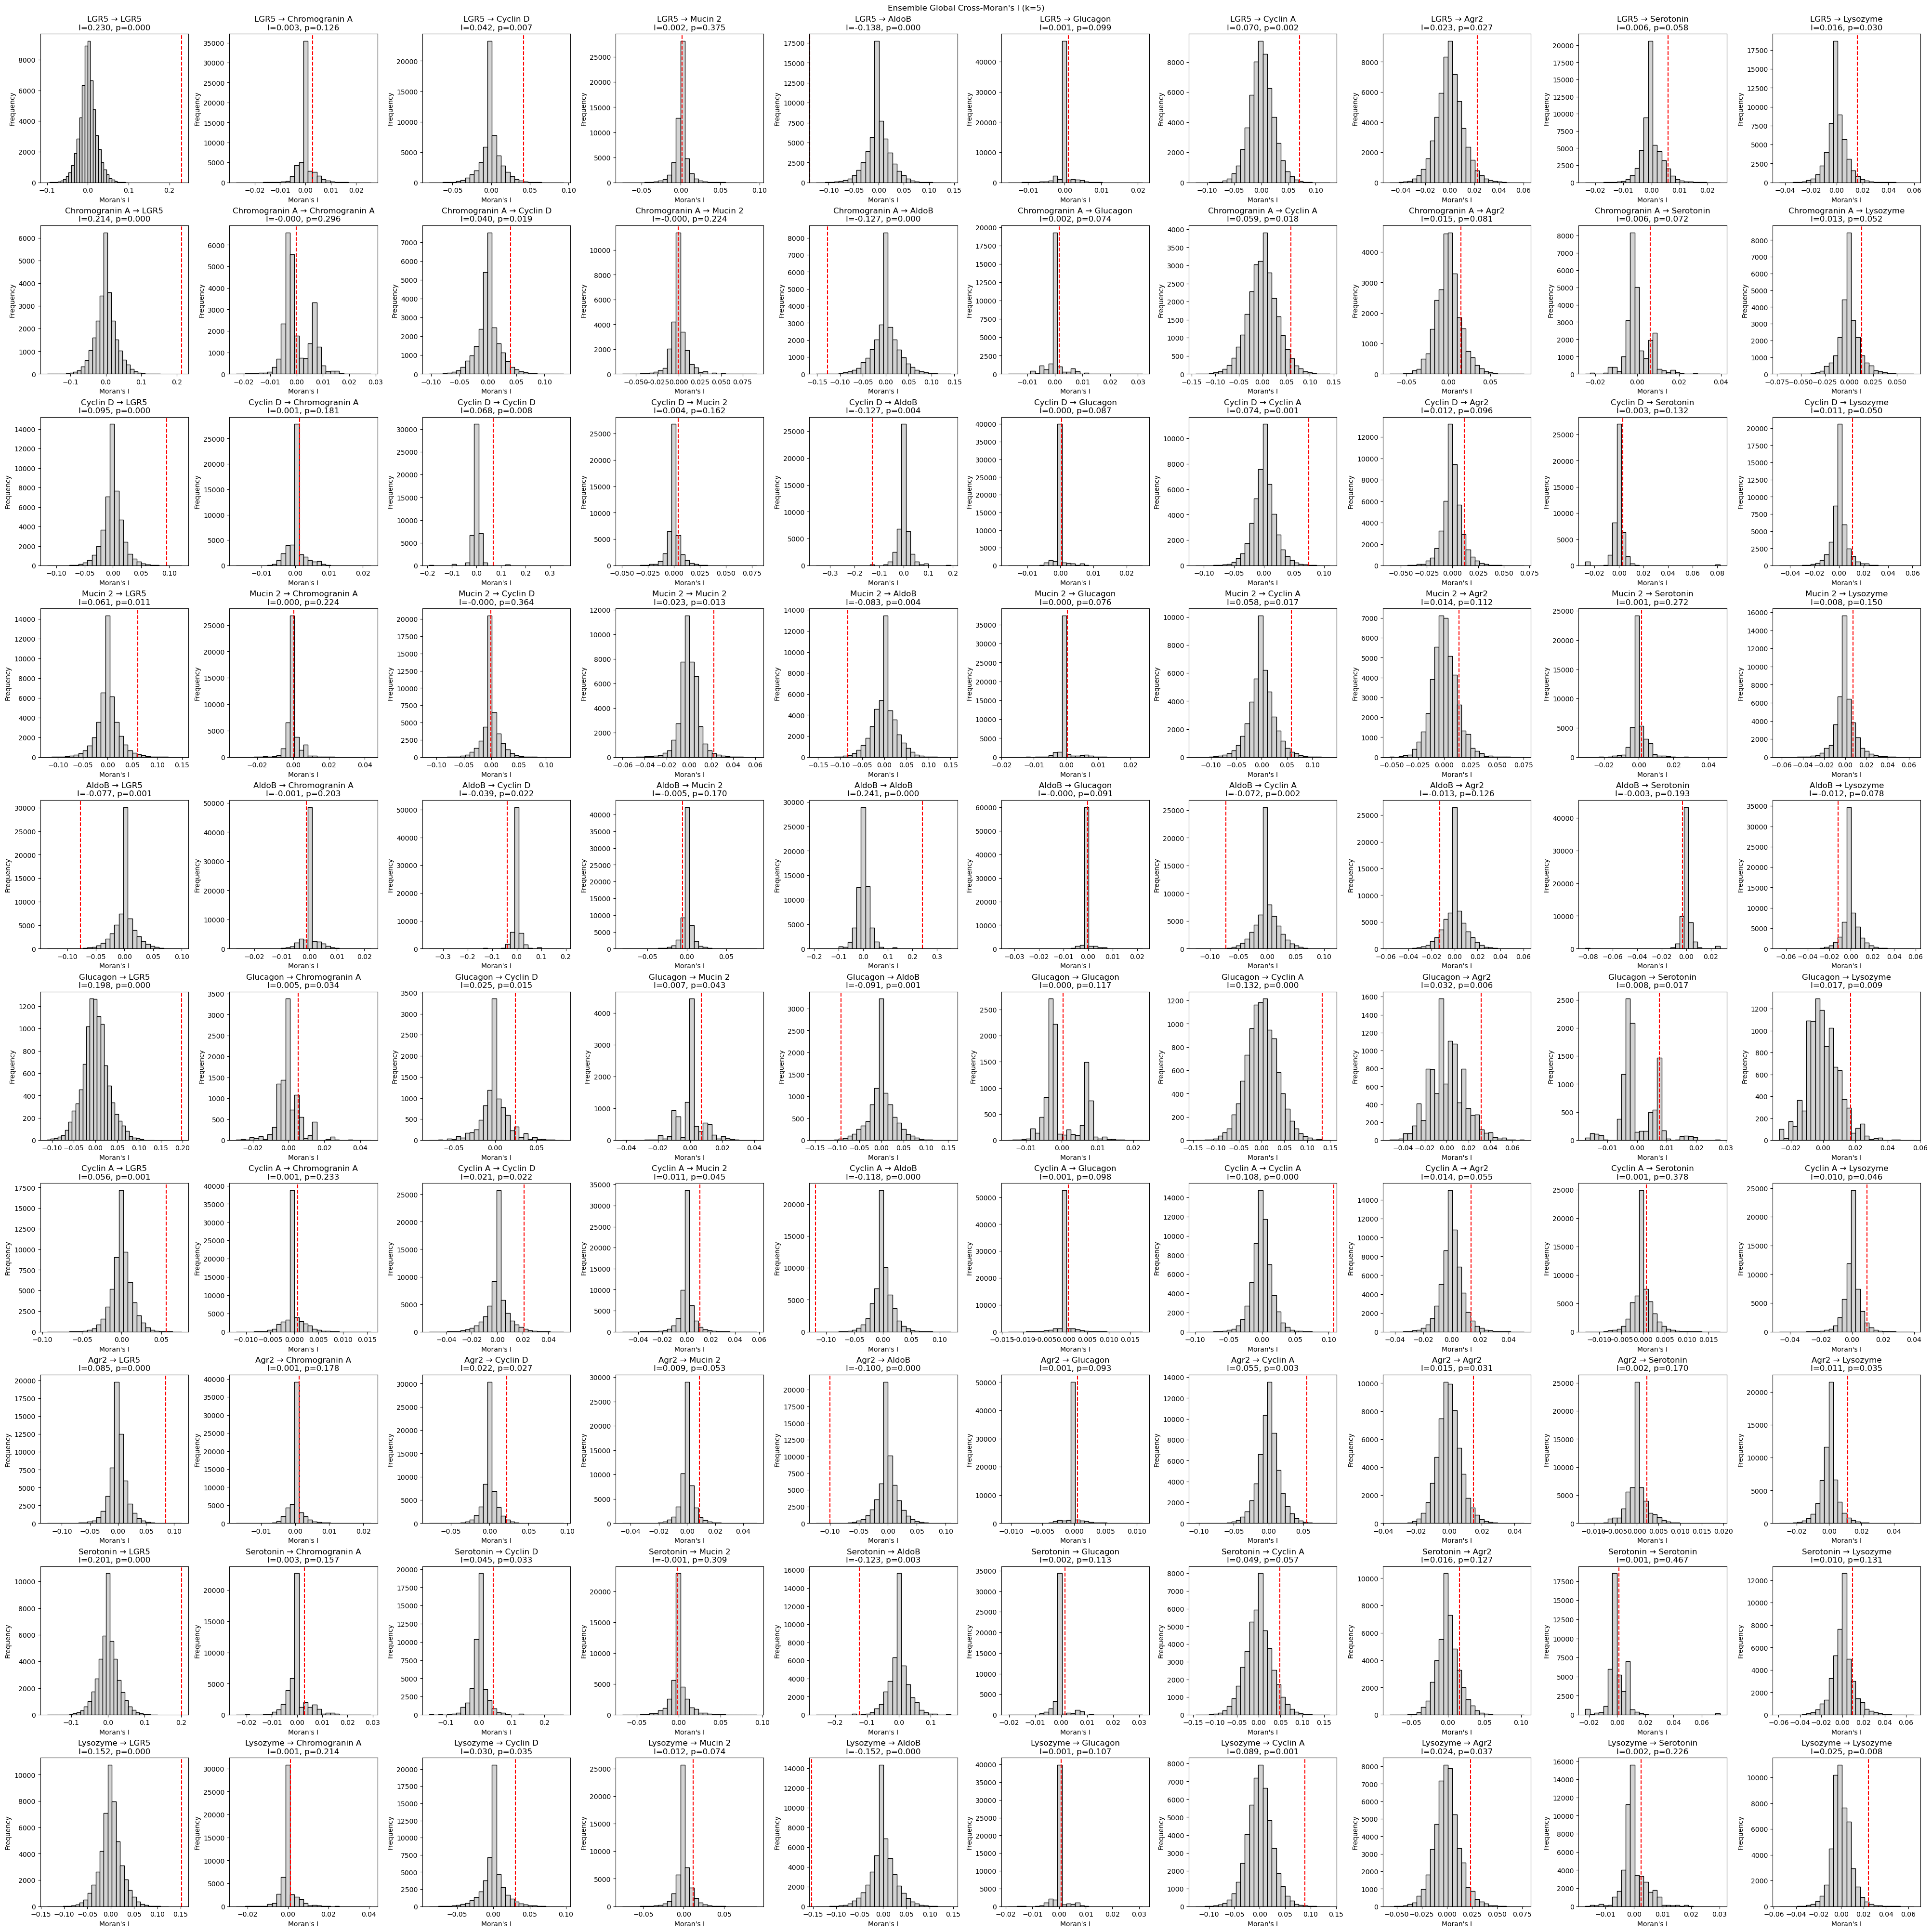

In [ ]:
# --- Plot ensemble global cross-Moran's I ---
for k in k_values:
    perm_all = ensemble_global_perm[k]
    obs_mean = ensemble_global_I_mean[k]
    p_val = ensemble_p_values[k]

    fig, axes = plt.subplots(n_markers, n_markers, figsize=(4*n_markers, 4*n_markers), constrained_layout=True)
    for i in range(n_markers):
        for j in range(n_markers):
            ax = axes[i, j] if n_markers > 1 else axes
            perm_data = perm_all[:, i, j]
            perm_data = perm_data[~np.isnan(perm_data)]
            obs_value = obs_mean[i, j]
            if len(perm_data) > 0:
                ax.hist(perm_data, bins=30, color="lightgray", edgecolor="black")
                ax.axvline(obs_value, color="red", linestyle="--")
            ax.set_title(f"{mesh.marker_names[i]} → {mesh.marker_names[j]}\nI={obs_value:.3f}, p={p_val[i,j]:.3f}")
            ax.set_xlabel("Moran's I")
            ax.set_ylabel("Frequency")
    plt.suptitle(f"Ensemble Global Cross-Moran's I (k={k})")
    plt.show()


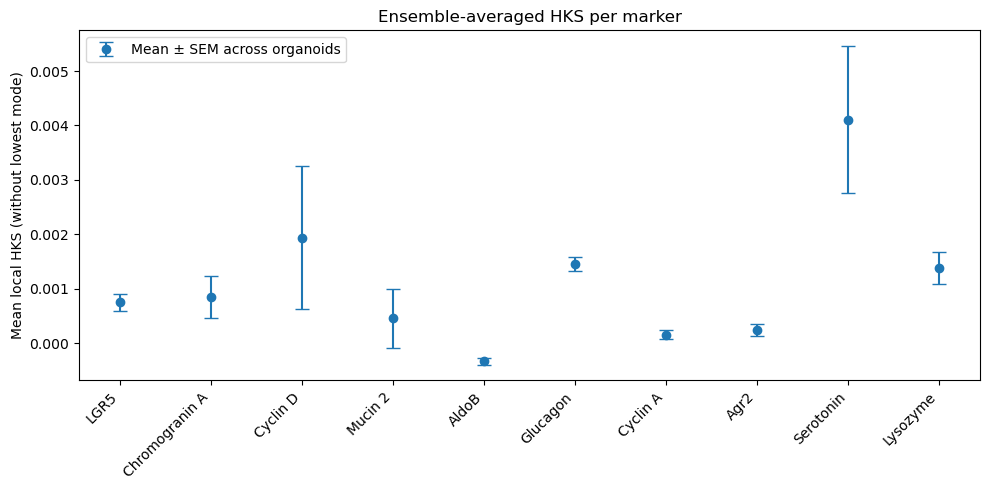

In [78]:
# Convert lists → arrays for easier aggregation
# Shape: (n_organoids, n_markers)
hks_cell_mean_all = np.array(hks_cell_mean_all)
hks_cell_std_all  = np.array(hks_cell_std_all)

# Number of organoids
n_org = hks_cell_mean_all.shape[0]

# --- Compute aggregated statistics ---
# Ensemble mean across organoids for each marker
mean_across_organoids = np.nanmean(hks_cell_mean_all, axis=0)       # (n_markers,)

# Ensemble standard error (SEM) = std / sqrt(n)
sem_across_organoids = np.nanstd(hks_cell_mean_all, axis=0, ddof=1) / np.sqrt(n_org)

# (Optional) Also compute variability of within-organoid std if needed
std_across_organoids = np.nanmean(hks_cell_std_all, axis=0)         # (n_markers,)

# Ensure 1D arrays
mean_across_organoids = mean_across_organoids.squeeze()
sem_across_organoids = sem_across_organoids.squeeze()

# --- Plot aggregated results ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(mesh.marker_names))
ax.errorbar(
    x,
    mean_across_organoids,
    yerr=sem_across_organoids,
    fmt='o',
    capsize=5,
    label='Mean ± SEM across organoids'
)

ax.set_xticks(x)
ax.set_xticklabels(mesh.marker_names, rotation=45, ha='right')
ax.set_ylabel("Mean local HKS (without lowest mode)")
ax.set_title("Ensemble-averaged HKS per marker")
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2779592/1165281129.py:7: RuntimeWarning: Mean of empty slice
  mean_profiles = np.nanmean(hks_profile_all, axis=0)
/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


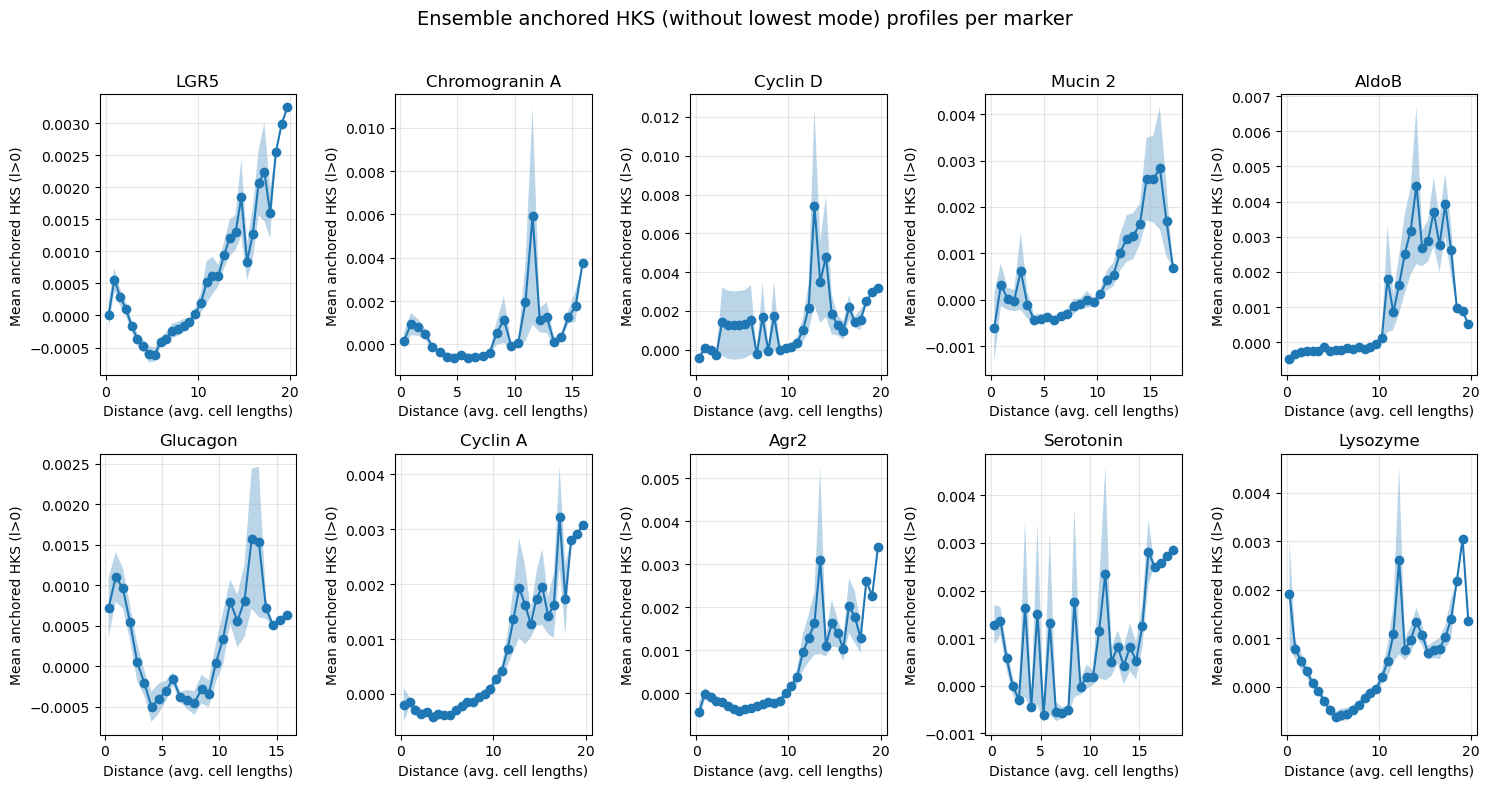

In [79]:
# Stack results across organoids
# shape: (n_organoids, n_markers, nbins)
hks_profile_all = np.stack(hks_profile_all, axis=0)

# Compute mean and SEM across organoids for each marker and bin
# shape: (n_markers, nbins)
mean_profiles = np.nanmean(hks_profile_all, axis=0)
sem_profiles = np.nanstd(hks_profile_all, axis=0) / np.sqrt(np.sum(~np.isnan(hks_profile_all), axis=0))

num_markers = mean_profiles.shape[0]

# Plot each marker's anchored profile
fig, axes = plt.subplots(
    2, int(np.ceil(num_markers / 2)),
    figsize=(3 * int(np.ceil(num_markers / 2)), 8),
    sharex=False, sharey=False
)
axes = axes.ravel()

for m_idx in range(num_markers):
    ax = axes[m_idx]
    m_mean = mean_profiles[m_idx]
    m_sem = sem_profiles[m_idx]

    ax.plot(bin_centers, m_mean, 'o-', label=mesh.marker_names[m_idx])
    ax.fill_between(
        bin_centers,
        m_mean - m_sem,
        m_mean + m_sem,
        alpha=0.3
    )

    ax.set_title(mesh.marker_names[m_idx])
    ax.set_xlabel("Distance (avg. cell lengths)")
    ax.set_ylabel("Mean anchored HKS (l>0)")
    ax.grid(True, alpha=0.3)

# Remove unused subplots if number of markers isn't a multiple of 3
for ax in axes[num_markers:]:
    ax.axis('off')

fig.suptitle("Ensemble anchored HKS (without lowest mode) profiles per marker", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()